# Copa 2026 — Simulation Central
End-to-end pipeline: data → model → predictions → visualizations → JSON export  
Run top-to-bottom for Round 1. Re-run after entering real results for subsequent rounds.

## Section 0 — Configuration & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
from scipy.stats import poisson
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_style('darkgrid')
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_DIR   = Path('data')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

MAX_GOALS  = 8
REF_DATE   = pd.Timestamp('2026-06-01')
N_SIM      = 10_000   # Monte Carlo runs
FORM_N     = 10       # last N matches for form calculation
W_A, W_B   = 0.40, 0.60  # ensemble weights

In [2]:

# Load group config
with open('copa2026_groups.json', encoding='utf-8') as f:
    cfg = json.load(f)

GROUPS    = cfg['groups']           # {A: {teams:[...], r1:[...]}, ...}
TEAM_META = cfg['team_meta']        # {team: {iso2, confederation}}
TEAM_TO_GROUP = {t: g for g, v in GROUPS.items() for t in v['teams']}
COPA_TEAMS = list(TEAM_META.keys())

print(f'{len(COPA_TEAMS)} Copa 2026 teams across {len(GROUPS)} groups')


48 Copa 2026 teams across 12 groups


In [3]:
# Single data source: all international matches including Copa 2026 group stage
df = pd.read_parquet(DATA_DIR / 'matches.parquet')
df['date'] = pd.to_datetime(df['date'])
print(f'matches.parquet: {len(df):,} rows  ({df["date"].min().date()} to {df["date"].max().date()})')
print(f'Columns: {list(df.columns)}')

Unified: 49,477 matches  (1872-11-30 → 2026-06-27)
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_elo_pre', 'away_elo_pre', 'home_elo_post', 'away_elo_post', 'elo_diff', 'odds_away', 'odds_draw', 'odds_home', 'impl_home', 'impl_draw', 'impl_away', 'overround', 'fair_home', 'fair_draw', 'fair_away', 'odds_btts_no', 'odds_btts_yes', 'impl_btts_yes', 'over_1.5', 'under_1.5', 'over_2.5', 'under_2.5', 'over_3.5', 'under_3.5', 'over_4.5', 'under_4.5', 'spr_home_-2.5', 'spr_away_-2.5', 'spr_home_-2.0', 'spr_away_-2.0', 'spr_home_-1.5', 'spr_away_-1.5', 'spr_home_-1.0', 'spr_away_-1.0', 'spr_home_-0.5', 'spr_away_-0.5', 'spr_home_+0.0', 'spr_away_+0.0', 'spr_home_+0.5', 'spr_away_+0.5', 'spr_home_+1.0', 'spr_away_+1.0', 'spr_home_+1.5', 'spr_away_+1.5', 'spr_home_+2.0', 'spr_away_+2.0', 'spr_home_+2.5', 'spr_away_+2.5']


In [4]:
# Copa 2026 group stage: date >= 2026-06-11, tournament == FIFA World Cup
wc = df[(df['date'] >= '2026-06-11') & (df['tournament'] == 'FIFA World Cup')].reset_index(drop=True)
wc['date'] = pd.to_datetime(wc['date'])

copa_r1 = wc.iloc[0:24].copy()
copa_r2 = wc.iloc[24:48].copy()
copa_r3 = wc.iloc[48:72].copy()

print(f'Copa 2026 group stage: {len(wc)} matches  R1={len(copa_r1)}  R2={len(copa_r2)}  R3={len(copa_r3)}')
copa_r1[['date','home_team','away_team','home_elo_pre','away_elo_pre']].head(8)

Copa schedule: 72 matches  R1=24  R2=24  R3=24


,date,home_team,away_team,home_elo_pre,away_elo_pre
0,2026-06-11,Mexico,South Africa,1875.000,1517.000
1,2026-06-11,South Korea,Czech Republic,1758.000,1740.000
2,2026-06-12,Canada,Bosnia and Herzegovina,1788.000,1595.000
3,2026-06-12,United States,Paraguay,1726.000,1834.000
4,2026-06-13,Qatar,Switzerland,1421.000,1891.000
5,2026-06-13,Brazil,Morocco,1991.000,1827.000
6,2026-06-13,Haiti,Scotland,1548.000,1782.000
7,2026-06-13,Australia,Turkey,1777.000,1911.000


In [5]:
# Training set: all historical matches before the tournament
train = df[
    df['date'] < '2026-06-11'
].dropna(subset=['home_score','away_score','home_elo_pre','away_elo_pre']).copy()
train['home_score'] = train['home_score'].astype(int)
train['away_score'] = train['away_score'].astype(int)
train['days_ago']   = (REF_DATE - train['date']).dt.days
train['elo_diff']   = train['home_elo_pre'] - train['away_elo_pre']
print(f'Training matches: {len(train):,}')

# Validate team name coverage against group config
wc_teams  = set(wc['home_team']) | set(wc['away_team'])
cfg_teams = set(COPA_TEAMS)
not_in_wc  = sorted(cfg_teams - wc_teams)
not_in_cfg = sorted(wc_teams  - cfg_teams)
if not_in_wc:
    print('In config but NOT in wc:', not_in_wc)
if not_in_cfg:
    print('In wc but NOT in config:', not_in_cfg)
if not not_in_wc and not not_in_cfg:
    print('Team name coverage: all 48 teams match')

Training matches: 48,115
Team name coverage: all teams match  ✓


## Section 1 — Team Arrival Profiles
*How does each team arrive at the World Cup?*

In [6]:
# Current ELO for all 48 Copa teams (from their first WC match entry)
elo_now = {}
for team in COPA_TEAMS:
    rows = wc[wc['home_team'] == team]['home_elo_pre'].dropna()
    if rows.empty:
        rows = wc[wc['away_team'] == team]['away_elo_pre'].dropna()
    elo_now[team] = float(rows.iloc[0]) if not rows.empty else np.nan

elo_df = pd.DataFrame([
    {'Team': t, 'ELO': elo_now[t], 'Group': TEAM_TO_GROUP[t],
     'Confederation': TEAM_META[t]['confederation']}
    for t in COPA_TEAMS
]).sort_values('ELO', ascending=False).reset_index(drop=True)
elo_df['ELO_Rank'] = range(1, len(elo_df) + 1)

print('Top 10 teams by ELO:')
elo_df.head(10)

Top 10 teams by ELO:


,Team,ELO,Group,Confederation,ELO_Rank
0,Spain,2157.000,H,UEFA,1
1,Argentina,2115.000,J,CONMEBOL,2
2,France,2063.000,I,UEFA,3
3,England,2024.000,L,UEFA,4
4,Brazil,1991.000,C,CONMEBOL,5
5,Portugal,1989.000,K,UEFA,6
6,Colombia,1982.000,K,CONMEBOL,7
7,Netherlands,1948.000,F,UEFA,8
8,Ecuador,1938.000,E,CONMEBOL,9
9,Germany,1932.000,E,UEFA,10


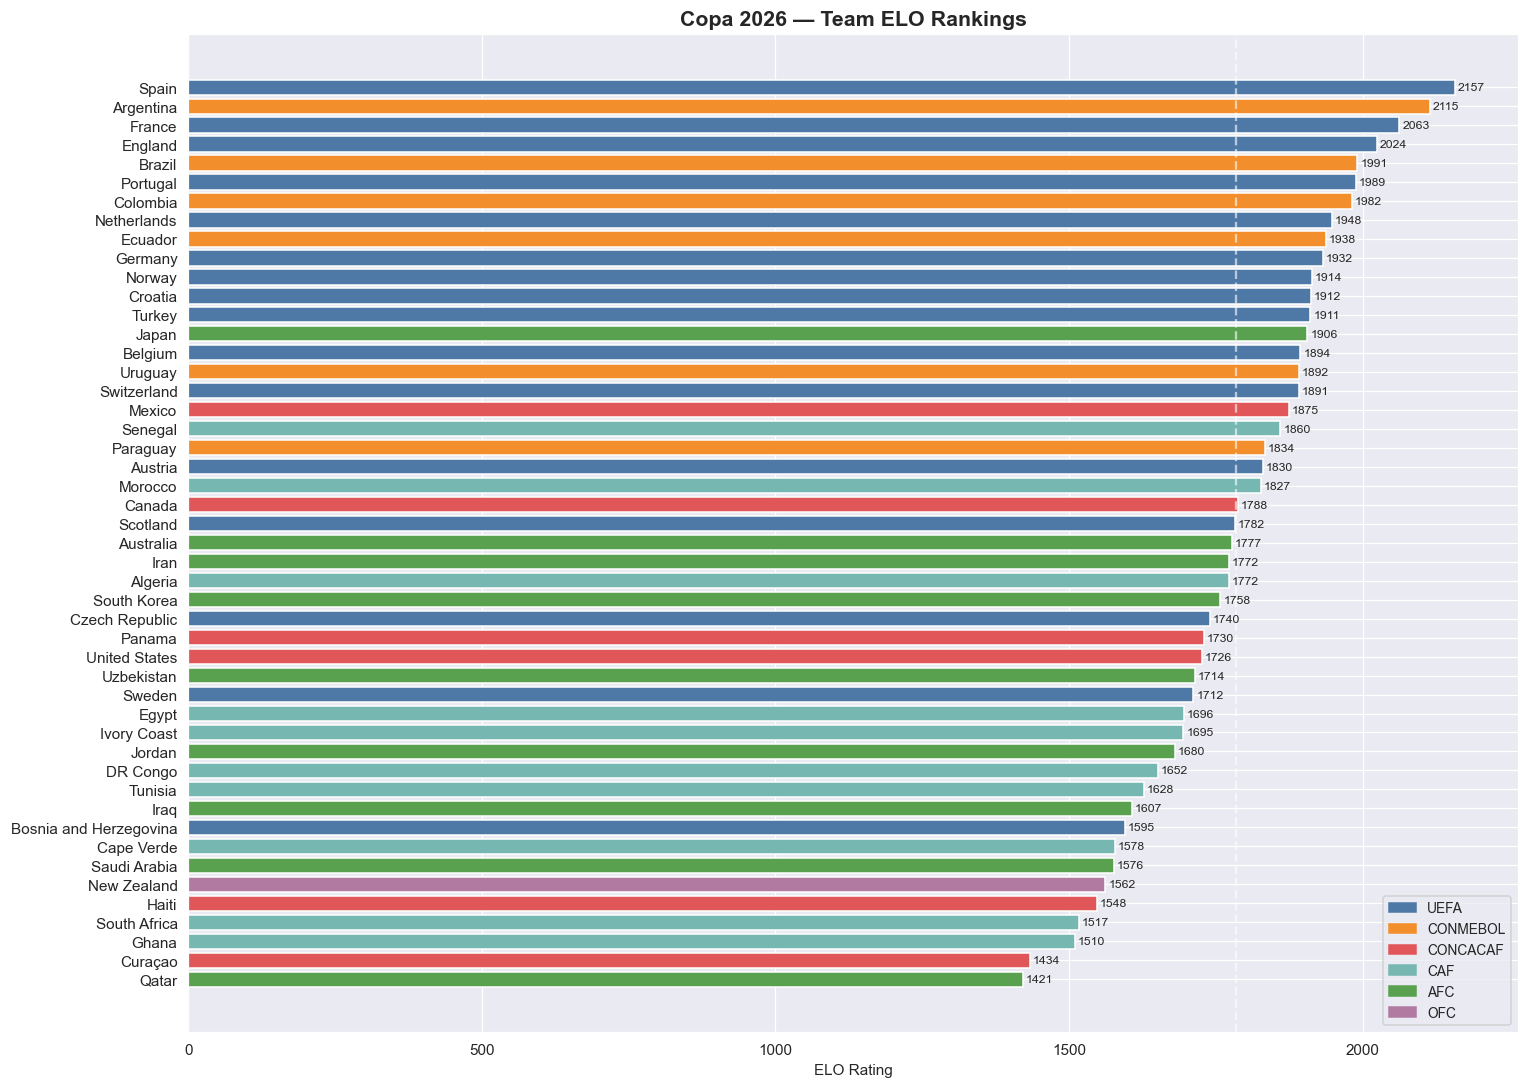

In [7]:
# ELO ranking bar chart — all 48 teams
conf_colors = {
    'UEFA': '#4e79a7', 'CONMEBOL': '#f28e2b', 'CONCACAF': '#e15759',
    'CAF': '#76b7b2', 'AFC': '#59a14f', 'OFC': '#b07aa1'
}
colors = [conf_colors[TEAM_META[t]['confederation']] for t in elo_df['Team']]

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(elo_df['Team'][::-1], elo_df['ELO'][::-1], color=colors[::-1])
ax.set_xlabel('ELO Rating')
ax.set_title('Copa 2026 — Team ELO Rankings', fontsize=14, fontweight='bold')
ax.axvline(elo_df['ELO'].mean(), color='white', lw=1.5, ls='--', alpha=0.6, label='Average')

# Add ELO values as text
for bar, val in zip(bars[::-1], elo_df['ELO']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8)

legend_patches = [mpatches.Patch(color=c, label=k) for k,c in conf_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'elo_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

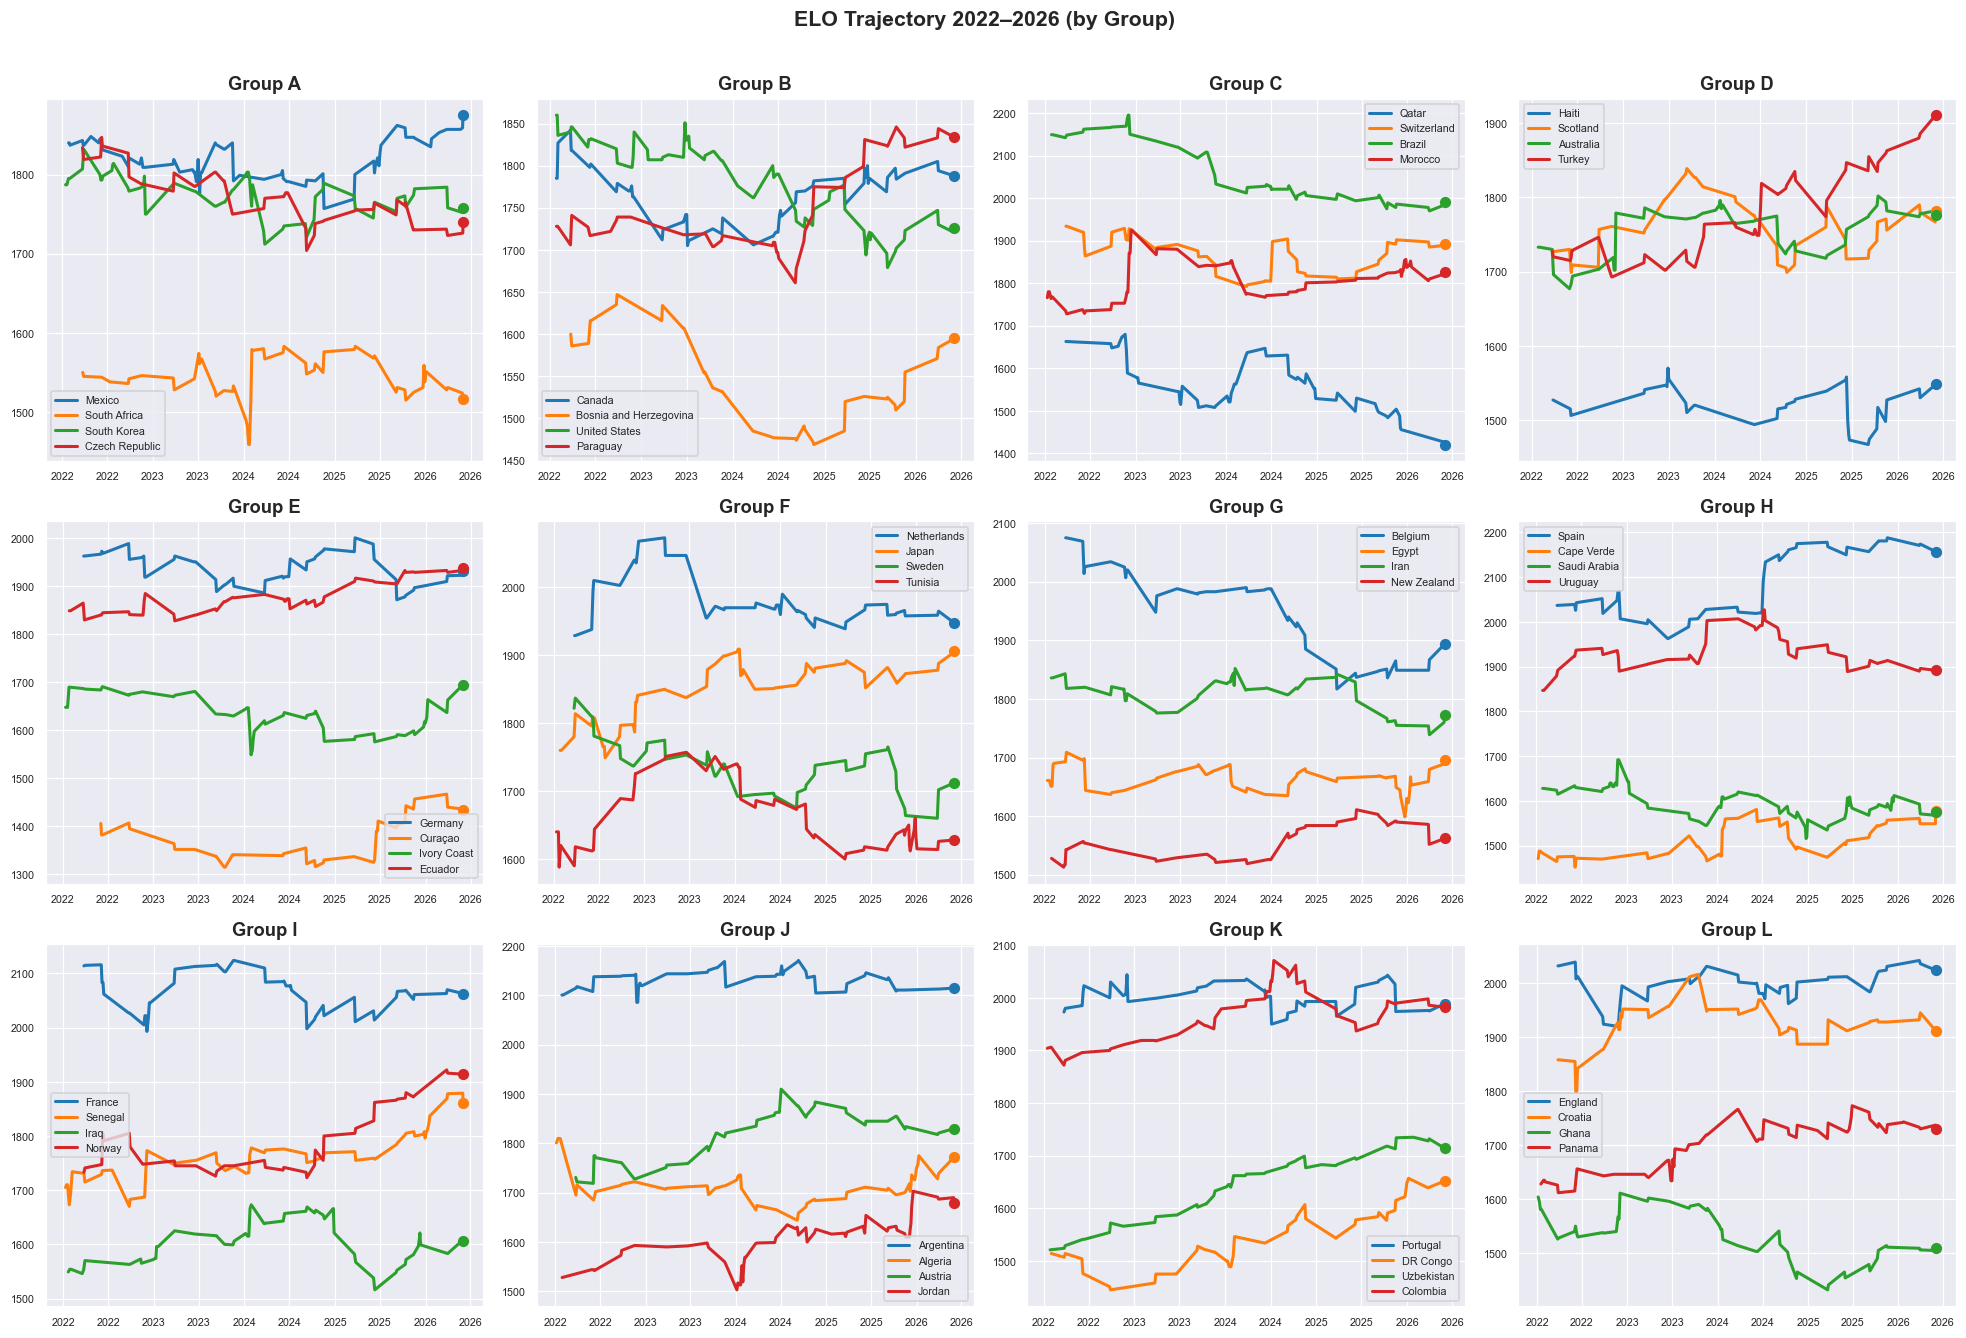

In [8]:
# ELO trajectory for each team — last 4 years
# Uses all matches from unified where the team appeared
TRAJ_FROM = '2022-01-01'

def get_elo_series(team):
    """Return dated ELO series for a team from training data."""
    home = train[train['home_team'] == team][['date','home_elo_pre']].rename(columns={'home_elo_pre':'elo'})
    away = train[train['away_team'] == team][['date','away_elo_pre']].rename(columns={'away_elo_pre':'elo'})
    s = pd.concat([home, away]).sort_values('date')
    s = s[s['date'] >= TRAJ_FROM]
    # Add current ELO as final point
    final = pd.DataFrame({'date': [REF_DATE], 'elo': [elo_now[team]]})
    return pd.concat([s, final]).drop_duplicates('date').set_index('date')['elo']

# Plot small multiples — one per group
GROUP_COLORS = plt.cm.tab10.colors

fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharey=False)
axes = axes.flatten()

for ax, (group_name, group_data) in zip(axes, GROUPS.items()):
    for i, team in enumerate(group_data['teams']):
        s = get_elo_series(team)
        if len(s) > 1:
            ax.plot(s.index, s.values, label=team, color=GROUP_COLORS[i], lw=2)
            ax.scatter([s.index[-1]], [s.values[-1]], color=GROUP_COLORS[i], s=40, zorder=5)
    ax.set_title(f'Group {group_name}', fontweight='bold')
    ax.legend(fontsize=7, loc='best')
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

fig.suptitle('ELO Trajectory 2022–2026 (by Group)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'elo_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Recent form: last FORM_N matches per team from unified (before Copa start)
recent = train[train['date'] >= '2024-01-01'].copy()

def get_form(team, n=FORM_N):
    """Return last N matches for a team as list of dicts."""
    home = recent[recent['home_team'] == team][[
        'date','home_team','away_team','home_score','away_score','tournament'
    ]].assign(side='home')
    away = recent[recent['away_team'] == team][[
        'date','home_team','away_team','home_score','away_score','tournament'
    ]].assign(side='away')
    combined = pd.concat([home, away]).sort_values('date', ascending=False).head(n)

    records = []
    for _, r in combined.iterrows():
        if r['side'] == 'home':
            gf, ga, opp = r['home_score'], r['away_score'], r['away_team']
        else:
            gf, ga, opp = r['away_score'], r['home_score'], r['home_team']
        result = 'W' if gf > ga else ('D' if gf == ga else 'L')
        records.append({
            'date': r['date'], 'opponent': opp, 'gf': int(gf), 'ga': int(ga),
            'result': result, 'tournament': r['tournament']
        })
    return records

def form_score(records):
    """Weighted form score: recent matches worth more."""
    weights = np.exp(-0.003 * np.arange(len(records)))
    pts = np.array([3 if r['result']=='W' else (1 if r['result']=='D' else 0)
                    for r in records])
    return round(float(np.dot(pts, weights) / weights.sum()), 3) if len(records) else np.nan

# Build form profile for every Copa team
form_profiles = {}
for team in COPA_TEAMS:
    records = get_form(team)
    gf_list = [r['gf'] for r in records]
    ga_list = [r['ga'] for r in records]
    form_profiles[team] = {
        'records':    records,
        'form_score': form_score(records),
        'avg_gf':     round(np.mean(gf_list), 2) if gf_list else np.nan,
        'avg_ga':     round(np.mean(ga_list), 2) if ga_list else np.nan,
        'w':  sum(1 for r in records if r['result'] == 'W'),
        'd':  sum(1 for r in records if r['result'] == 'D'),
        'l':  sum(1 for r in records if r['result'] == 'L'),
    }

# Summary table
form_df = pd.DataFrame([
    {'Team': t, 'Group': TEAM_TO_GROUP[t], 'ELO': elo_now[t],
     'Form': form_profiles[t]['form_score'],
     'W': form_profiles[t]['w'], 'D': form_profiles[t]['d'], 'L': form_profiles[t]['l'],
     'Avg GF': form_profiles[t]['avg_gf'], 'Avg GA': form_profiles[t]['avg_ga']}
    for t in COPA_TEAMS
]).sort_values('Form', ascending=False).reset_index(drop=True)

print(f'Form profiles built (last {FORM_N} matches since 2024-01-01):')
form_df.head(12)

Form profiles built (last 10 matches since 2024-01-01):


,Team,Group,ELO,Form,W,D,L,Avg GF,Avg GA
0,France,I,2063.000,2.504,8,1,1,2.700,1.100
1,Argentina,J,2115.000,2.502,8,1,1,2.500,0.400
2,Austria,J,1830.000,2.498,8,1,1,2.800,0.500
3,Croatia,L,1912.000,2.496,8,1,1,2.900,0.800
4,Germany,E,1932.000,2.407,8,0,2,2.600,0.900
5,Morocco,C,1827.000,2.400,7,3,0,2.000,0.300
6,Netherlands,F,1948.000,2.398,7,3,0,3.000,0.600
7,Spain,H,2157.000,2.398,7,3,0,3.100,0.800
8,Japan,F,1906.000,2.305,7,2,1,1.900,0.600
9,DR Congo,K,1652.000,2.298,7,2,1,1.200,0.300


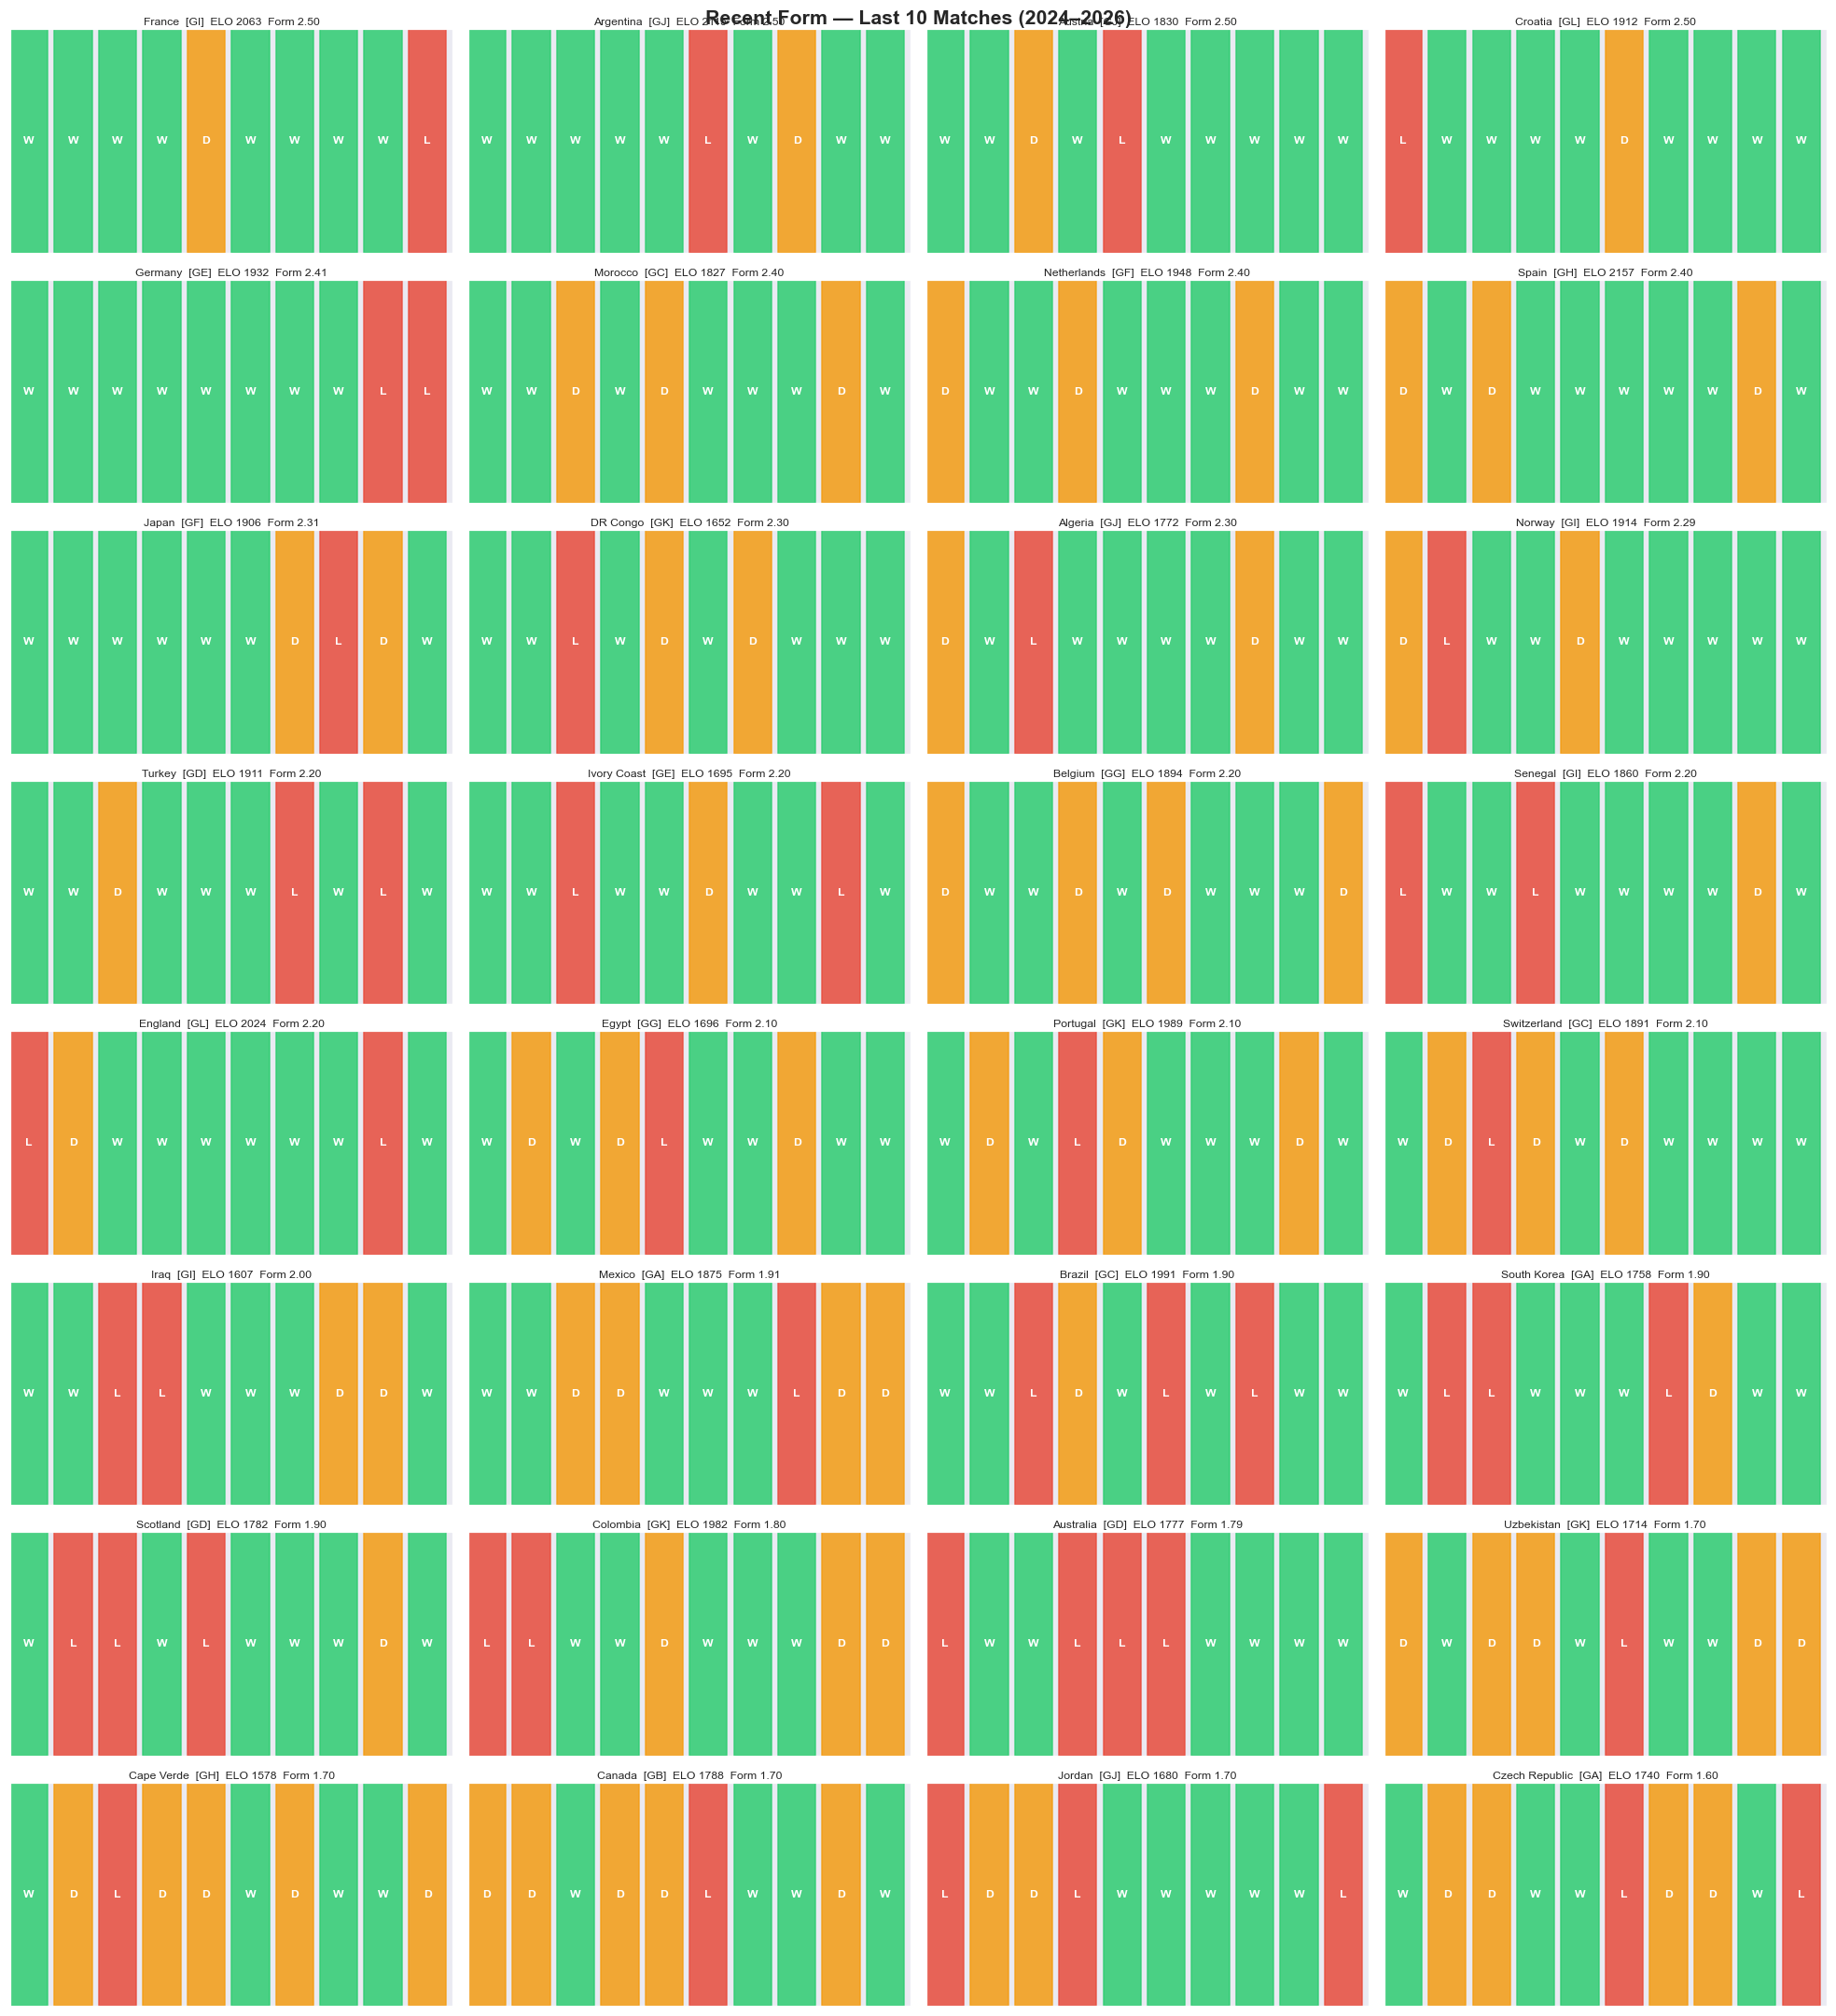

In [10]:
# Form strip visualization — all 48 teams
result_colors = {'W': '#2ecc71', 'D': '#f39c12', 'L': '#e74c3c'}

fig, axes = plt.subplots(12, 4, figsize=(18, 30))
axes = axes.flatten()

sorted_teams = form_df['Team'].tolist()
for ax, team in zip(axes, sorted_teams):
    records = form_profiles[team]['records'][:FORM_N]
    results = [r['result'] for r in records]
    for i, res in enumerate(results):
        ax.add_patch(plt.Rectangle((i, 0), 0.85, 1,
                                    color=result_colors[res], alpha=0.85))
        ax.text(i + 0.425, 0.5, res, ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
    ax.set_xlim(0, FORM_N)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(
        f'{team}  [G{TEAM_TO_GROUP[team]}]  ELO {elo_now[team]:.0f}  '
        f'Form {form_profiles[team]["form_score"]:.2f}',
        fontsize=8, pad=3
    )

for ax in axes[len(sorted_teams):]:
    ax.axis('off')

fig.suptitle(f'Recent Form — Last {FORM_N} Matches (2024–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'form_strips.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2 — Group Overview
*Relative strength and competitiveness within each group*

In [11]:
# Group summary table: teams ranked by ELO within each group
group_tables = {}
for g, data in GROUPS.items():
    rows = []
    for team in data['teams']:
        rows.append({
            'Team':       team,
            'ELO':        elo_now[team],
            'ELO Rank':   elo_df[elo_df['Team'] == team]['ELO_Rank'].values[0],
            'Form':       form_profiles[team]['form_score'],
            'W/D/L':      f"{form_profiles[team]['w']}/{form_profiles[team]['d']}/{form_profiles[team]['l']}",
            'Avg GF':     form_profiles[team]['avg_gf'],
            'Avg GA':     form_profiles[team]['avg_ga'],
            'Conf':       TEAM_META[team]['confederation'],
        })
    group_tables[g] = pd.DataFrame(rows).sort_values('ELO', ascending=False).reset_index(drop=True)

# Print all groups
for g, tbl in group_tables.items():
    print(f'\n=== Group {g} ===')
    display(tbl)


=== Group A ===


,Team,ELO,ELO Rank,Form,W/D/L,Avg GF,Avg GA,Conf
0,Mexico,1875.000,18,1.905,5/4/1,1.200,0.400,CONCACAF
1,South Korea,1758.000,28,1.897,6/1/3,1.800,1.200,AFC
2,Czech Republic,1740.000,29,1.603,4/4/2,1.800,1.300,UEFA
3,South Africa,1517.000,45,1.494,4/3/3,1.400,1.000,CAF



=== Group B ===


,Team,ELO,ELO Rank,Form,W/D/L,Avg GF,Avg GA,Conf
0,Paraguay,1834.000,20,1.399,4/2/4,1.000,1.000,CONMEBOL
1,Canada,1788.000,23,1.697,4/5/1,1.100,0.400,CONCACAF
2,United States,1726.000,31,1.603,5/1/4,1.800,1.700,CONCACAF
3,Bosnia and Herzegovina,1595.000,40,1.400,3/5/2,2.000,1.100,UEFA



=== Group C ===


...

,Team,ELO,ELO Rank,Form,W/D/L,Avg GF,Avg GA,Conf
0,Argentina,2115.000,2,2.502,8/1/1,2.500,0.400,CONMEBOL
1,Austria,1830.000,21,2.498,8/1/1,2.800,0.500,UEFA
2,Algeria,1772.000,27,2.297,7/2/1,2.300,0.500,CAF
3,Jordan,1680.000,36,1.695,5/2/3,1.900,1.600,AFC



=== Group K ===


,Team,ELO,ELO Rank,Form,W/D/L,Avg GF,Avg GA,Conf
0,Portugal,1989.000,6,2.098,6/3/1,2.600,1.000,UEFA
1,Colombia,1982.000,7,1.797,5/3/2,2.100,1.000,CONMEBOL
2,Uzbekistan,1714.000,32,1.700,4/5/1,1.500,0.700,AFC
3,DR Congo,1652.000,37,2.298,7/2/1,1.200,0.300,CAF



=== Group L ===


,Team,ELO,ELO Rank,Form,W/D/L,Avg GF,Avg GA,Conf
0,England,2024.000,4,2.197,7/1/2,2.200,0.500,UEFA
1,Croatia,1912.000,12,2.496,8/1/1,2.900,0.800,UEFA
2,Panama,1730.000,30,1.597,4/4/2,1.500,1.400,CONCACAF
3,Ghana,1510.000,46,1.291,4/1/5,1.400,1.300,CAF


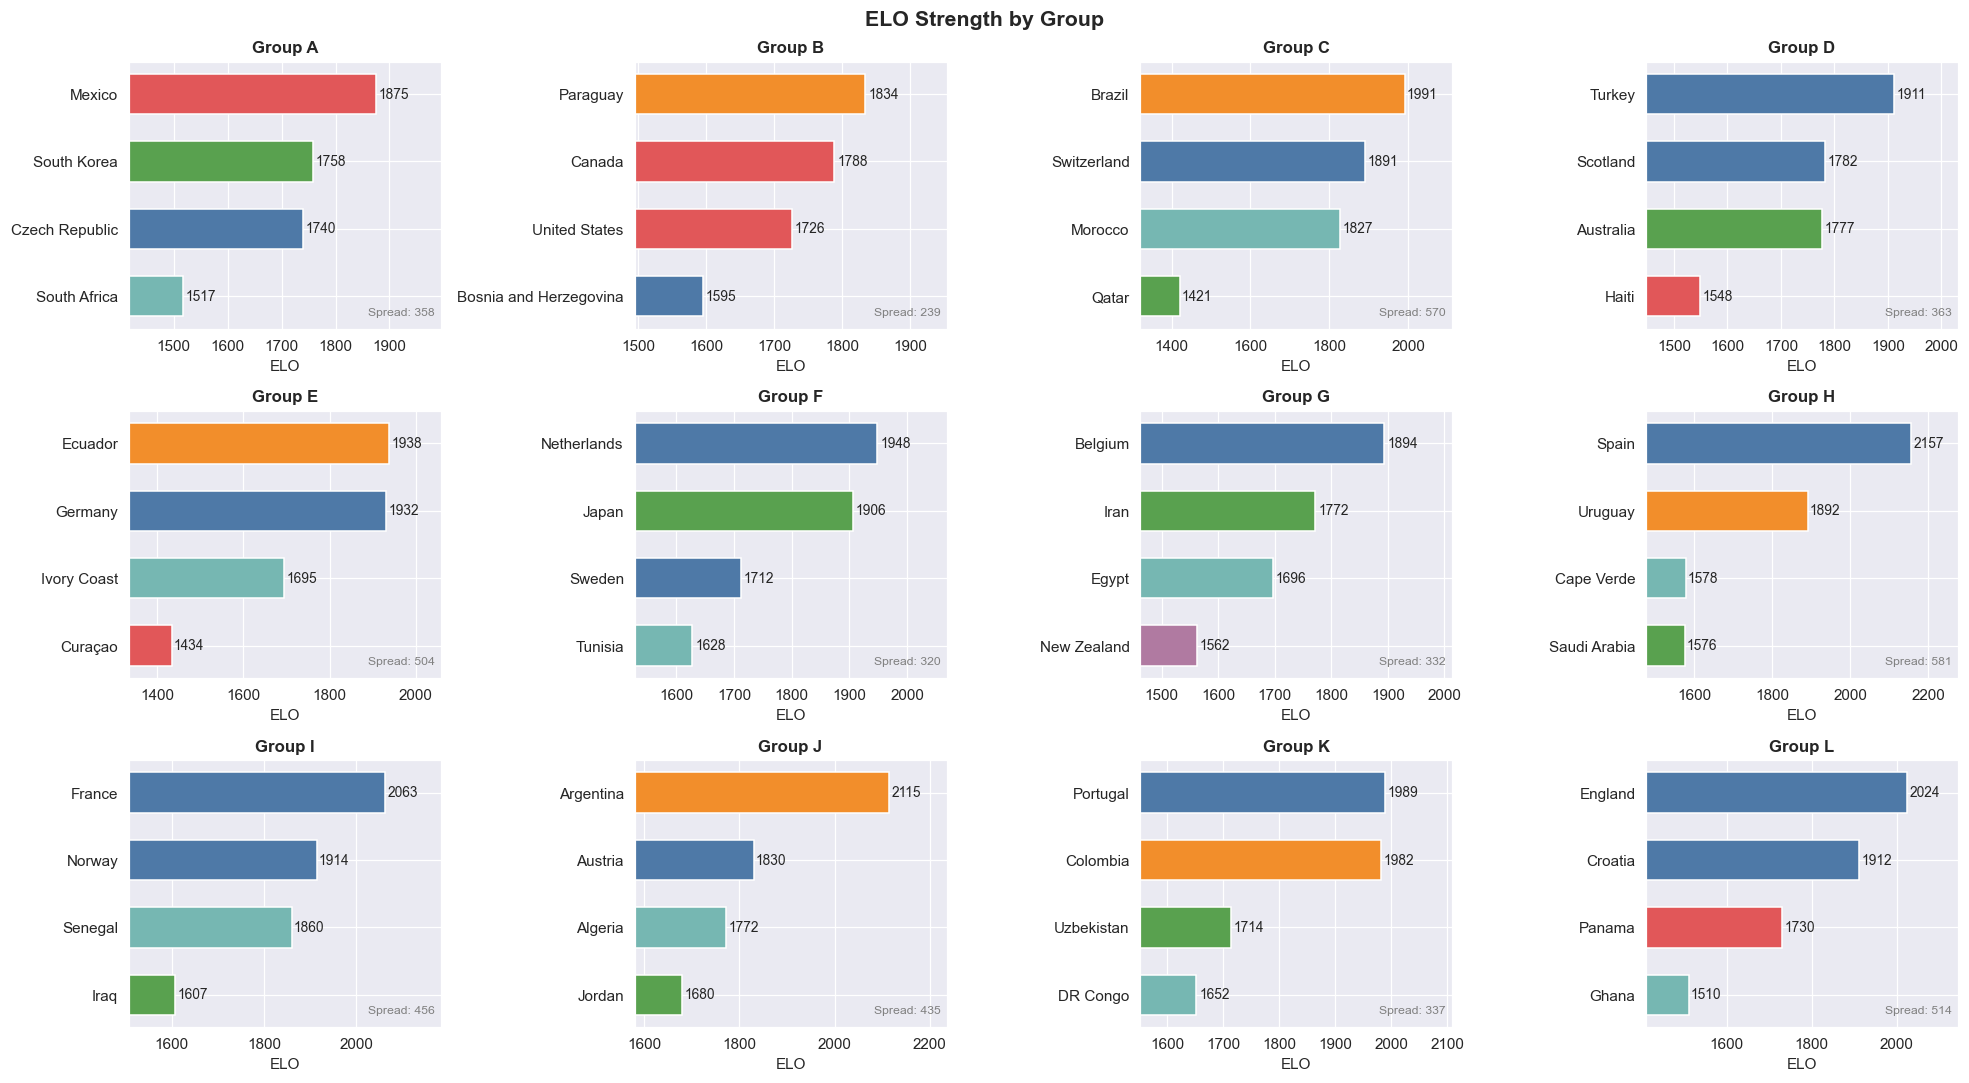


Groups by competitiveness (smaller spread = more balanced):
  Group B: 239 ELO spread
  Group F: 320 ELO spread
  Group G: 332 ELO spread
  Group K: 337 ELO spread
  Group A: 358 ELO spread
  Group D: 363 ELO spread
  Group J: 435 ELO spread
  Group I: 456 ELO spread
  Group E: 504 ELO spread
  Group L: 514 ELO spread
  Group C: 570 ELO spread
  Group H: 581 ELO spread


In [12]:
# Group competitiveness chart — ELO spread within each group
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, (g, tbl) in zip(axes, group_tables.items()):
    colors_g = [conf_colors[TEAM_META[t]['confederation']] for t in tbl['Team']]
    bars = ax.barh(tbl['Team'][::-1], tbl['ELO'][::-1], color=colors_g[::-1], height=0.6)
    ax.set_title(f'Group {g}', fontweight='bold', fontsize=11)
    ax.set_xlabel('ELO')
    min_elo = tbl['ELO'].min()
    max_elo = tbl['ELO'].max()
    ax.set_xlim(min_elo - 100, max_elo + 120)
    for bar, val in zip(bars[::-1], tbl['ELO']):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}', va='center', fontsize=9)
    # Spread annotation
    spread = max_elo - min_elo
    ax.text(0.98, 0.05, f'Spread: {spread:.0f}', transform=ax.transAxes,
            ha='right', fontsize=8, color='gray')

fig.suptitle('ELO Strength by Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'group_elo.png', dpi=150, bbox_inches='tight')
plt.show()

# Which group is most competitive (smallest ELO spread)?
spreads = {g: tbl['ELO'].max() - tbl['ELO'].min() for g, tbl in group_tables.items()}
print('\nGroups by competitiveness (smaller spread = more balanced):')
for g, s in sorted(spreads.items(), key=lambda x: x[1]):
    print(f'  Group {g}: {s:.0f} ELO spread')

## Section 3 — Model
*Build the prediction engine*

In [13]:
# Shared helpers
def scoreline_matrix(lam_h, lam_a, max_g=MAX_GOALS):
    ph = np.array([poisson.pmf(g, lam_h) for g in range(max_g + 1)])
    pa = np.array([poisson.pmf(g, lam_a) for g in range(max_g + 1)])
    ph[-1] = 1 - ph[:-1].sum()
    pa[-1] = 1 - pa[:-1].sum()
    return np.outer(ph, pa)

def matrix_to_markets(m, max_g=MAX_GOALS):
    rows, cols = np.mgrid[0:max_g+1, 0:max_g+1]
    out = {
        'p_home': float(m[rows > cols].sum()),
        'p_draw': float(np.diag(m).sum()),
        'p_away': float(m[rows < cols].sum()),
        'p_btts': float(m[1:, 1:].sum()),
        'over_2.5':  float(m[rows + cols > 2.5].sum()),
        'under_2.5': float(m[rows + cols < 2.5].sum()),
        'over_1.5':  float(m[rows + cols > 1.5].sum()),
        'under_1.5': float(m[rows + cols < 1.5].sum()),
        'over_3.5':  float(m[rows + cols > 3.5].sum()),
        'under_3.5': float(m[rows + cols < 3.5].sum()),
        'xg_home': float(sum(i * m[i, :].sum() for i in range(max_g + 1))),
        'xg_away': float(sum(j * m[:, j].sum() for j in range(max_g + 1))),
    }
    # Top scorelines
    scores = [(i, j, float(m[i, j])) for i in range(max_g+1) for j in range(max_g+1)]
    out['top_scorelines'] = sorted(scores, key=lambda x: -x[2])[:8]
    return out

In [14]:
# Model A — Poisson + Elo regression
XI_A = 0.003
train['w_a'] = np.exp(-XI_A * train['days_ago'])

X  = train[['elo_diff']].values
w  = train['w_a'].values
yh = np.log(train['home_score'].clip(1).values.astype(float))
ya = np.log(train['away_score'].clip(1).values.astype(float))

reg_home = LinearRegression().fit(X, yh, sample_weight=w)
reg_away = LinearRegression().fit(X, ya, sample_weight=w)

print(f'Model A — Home: log(λ) = {reg_home.intercept_:.4f} + {reg_home.coef_[0]:.6f} × elo_diff')
print(f'Model A — Away: log(λ) = {reg_away.intercept_:.4f} + {reg_away.coef_[0]:.6f} × elo_diff')

# Fit quality: predicted vs actual goals
pred_h = np.exp(reg_home.predict(X))
pred_a = np.exp(reg_away.predict(X))
print(f'\nWeighted MAE home goals: {np.average(np.abs(pred_h - train["home_score"]), weights=w):.3f}')
print(f'Weighted MAE away goals: {np.average(np.abs(pred_a - train["away_score"]), weights=w):.3f}')

def predict_a(elo_diff):
    lh = float(np.exp(reg_home.predict([[elo_diff]])[0]))
    la = float(np.exp(reg_away.predict([[elo_diff]])[0]))
    return matrix_to_markets(scoreline_matrix(lh, la)), lh, la

Model A — Home: log(λ) = 0.4277 + 0.000908 × elo_diff
Model A — Away: log(λ) = 0.3177 + -0.000766 × elo_diff

Weighted MAE home goals: 1.081
Weighted MAE away goals: 0.969


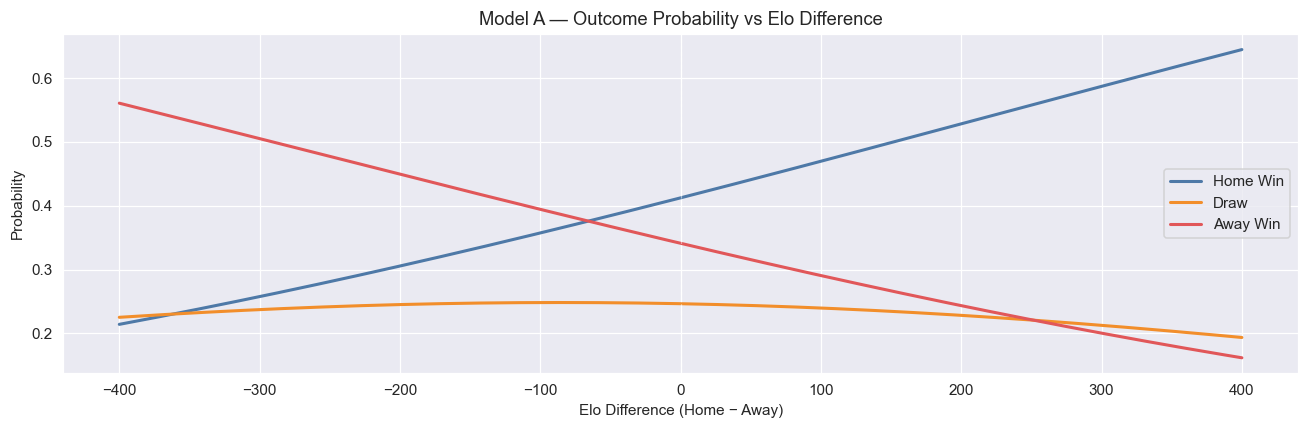

In [15]:
# Model A: predicted win/draw/loss probability vs Elo diff
elo_range = np.linspace(-400, 400, 200)
ph_list, pd_list, pa_list = [], [], []
for ed in elo_range:
    mk, _, _ = predict_a(ed)
    ph_list.append(mk['p_home']); pd_list.append(mk['p_draw']); pa_list.append(mk['p_away'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(elo_range, ph_list, label='Home Win', color='#4e79a7', lw=2)
ax.plot(elo_range, pd_list, label='Draw',     color='#f28e2b', lw=2)
ax.plot(elo_range, pa_list, label='Away Win', color='#e15759', lw=2)
ax.axvline(0, color='white', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Elo Difference (Home − Away)')
ax.set_ylabel('Probability')
ax.set_title('Model A — Outcome Probability vs Elo Difference')
ax.legend()
plt.tight_layout(); plt.show()

In [16]:
# Model B — Poisson GLM with team fixed effects (2010+, neutral venue)
XI_B       = 0.003
GLM_FROM   = '2010-01-01'
MIN_WEIGHT = 0.01   # drop matches where time-decay weight < this (~1500 days ago)
BASE_TEAM  = 'France'

glm_train = train[train['date'] >= GLM_FROM].copy()
glm_train['w_b'] = np.exp(-XI_B * glm_train['days_ago'])
glm_train = glm_train[glm_train['w_b'] >= MIN_WEIGHT].copy()
print(f'GLM training: {len(glm_train):,} matches  '
      f'(weight >= {MIN_WEIGHT}, cutoff ~{-np.log(MIN_WEIGHT)/XI_B:.0f} days ago)')

home_rows = pd.DataFrame({'goals':   glm_train['home_score'].values,
                           'attack':  glm_train['home_team'].values,
                           'defense': glm_train['away_team'].values,
                           'home':    1,
                           'weight':  glm_train['w_b'].values})
away_rows = pd.DataFrame({'goals':   glm_train['away_score'].values,
                           'attack':  glm_train['away_team'].values,
                           'defense': glm_train['home_team'].values,
                           'home':    0,
                           'weight':  glm_train['w_b'].values})
long = pd.concat([home_rows, away_rows], ignore_index=True)
long = long[np.isfinite(long['weight']) & (long['weight'] > 0)].copy()

teams_enc = sorted(t for t in set(long['attack']) | set(long['defense']) if t != BASE_TEAM)
t2i       = {t: i for i, t in enumerate(teams_enc)}
n_rows, n_teams = len(long), len(teams_enc)

atk_mat = np.zeros((n_rows, n_teams))
def_mat = np.zeros((n_rows, n_teams))
for idx, (atk, dfn) in enumerate(zip(long['attack'], long['defense'])):
    if atk in t2i: atk_mat[idx, t2i[atk]] = 1
    if dfn in t2i: def_mat[idx, t2i[dfn]] = 1

col_names = ([f'atk_{t}' for t in teams_enc] +
             [f'def_{t}' for t in teams_enc] +
             ['home'])
X_df = sm.add_constant(
    pd.DataFrame(np.hstack([atk_mat, def_mat, long[['home']].values]), columns=col_names),
    prepend=True
)
glm_res = sm.GLM(long['goals'].values, X_df,
                 family=sm.families.Poisson(),
                 freq_weights=long['weight'].values).fit(maxiter=300, disp=False)

print(f'GLM converged: {glm_res.converged}  |  Deviance: {glm_res.deviance:.1f}')

params    = glm_res.params
intercept = float(params['const'])
home_adv  = float(params['home'])
attack_b  = {BASE_TEAM: 0.0}
defense_b = {BASE_TEAM: 0.0}
for t in teams_enc:
    attack_b[t]  = float(params.get(f'atk_{t}', 0.0))
    defense_b[t] = float(params.get(f'def_{t}', 0.0))

print(f'Home advantage: {home_adv:.4f} (x{np.exp(home_adv):.3f} goals multiplier)')

def predict_b(home_team, away_team):
    # Neutral venue: no home advantage
    lh = float(np.exp(intercept + attack_b.get(home_team, 0.) - defense_b.get(away_team, 0.)))
    la = float(np.exp(intercept + attack_b.get(away_team, 0.) - defense_b.get(home_team, 0.)))
    return matrix_to_markets(scoreline_matrix(lh, la)), lh, la


ValueError: NaN, inf or invalid value detected in weights, estimation infeasible.

In [ ]:
# GLM ratings for all 48 Copa teams
glm_ratings = pd.DataFrame([{
    'Team':    t,
    'Group':   TEAM_TO_GROUP[t],
    'ELO':     elo_now[t],
    'Attack':  attack_b.get(t, np.nan),
    'Defense': defense_b.get(t, np.nan),
    'Net':     attack_b.get(t, 0.) - defense_b.get(t, 0.),
} for t in COPA_TEAMS]).sort_values('Net', ascending=False).reset_index(drop=True)

# Sanity check: GLM Net vs ELO should correlate
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(glm_ratings['ELO'], glm_ratings['Net'],
                c=[conf_colors[TEAM_META[t]['confederation']] for t in glm_ratings['Team']],
                s=80, zorder=3)
for _, row in glm_ratings.iterrows():
    ax.annotate(row['Team'], (row['ELO'], row['Net']), fontsize=6, alpha=0.8,
                xytext=(4, 2), textcoords='offset points')
corr = glm_ratings[['ELO','Net']].corr().iloc[0,1]
ax.set_xlabel('ELO Rating'); ax.set_ylabel('GLM Net (Attack − Defense)')
ax.set_title(f'GLM Net Rating vs ELO  (r = {corr:.2f})')
legend_patches = [mpatches.Patch(color=c, label=k) for k,c in conf_colors.items()]
ax.legend(handles=legend_patches, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'glm_vs_elo.png', dpi=150, bbox_inches='tight')
plt.show()

glm_ratings

In [ ]:
# Ensemble prediction function
def predict_match(home_team, away_team, elo_diff):
    """Return ensemble market probs, lambdas, and scoreline matrix."""
    mk_a, lh_a, la_a = predict_a(elo_diff)
    mk_b, lh_b, la_b = predict_b(home_team, away_team)

    mk_e = {}
    for key in mk_a:
        if key == 'top_scorelines':
            continue
        mk_e[key] = W_A * mk_a[key] + W_B * mk_b[key]

    # Ensemble expected goals
    lh_e = W_A * lh_a + W_B * lh_b
    la_e = W_A * la_a + W_B * la_b
    mat_e = scoreline_matrix(lh_e, la_e)

    # Top scorelines from ensemble matrix
    scores = [(i, j, float(mat_e[i,j])) for i in range(MAX_GOALS+1) for j in range(MAX_GOALS+1)]
    mk_e['top_scorelines'] = sorted(scores, key=lambda x: -x[2])[:8]
    mk_e['xg_home'] = lh_e
    mk_e['xg_away'] = la_e

    return mk_e, mat_e, mk_a, mk_b

# Quick test
mk, mat, _, _ = predict_match('Brazil', 'Morocco', 1991 - 1827)
print(f'Brazil vs Morocco: H={mk["p_home"]:.3f}  D={mk["p_draw"]:.3f}  A={mk["p_away"]:.3f}')
print(f'xG: Brazil {mk["xg_home"]:.2f}  Morocco {mk["xg_away"]:.2f}')
print(f'Most likely: {", ".join(f"{h}-{a} ({p:.1%})" for h,a,p in mk["top_scorelines"][:3])}')

## Section 4 — Round 1 Match Predictions
*One detailed block per match*

In [ ]:
# Compute predictions for all Round 1 matches
r1_predictions = []
for _, row in copa_r1.iterrows():
    ht, at = row['home_team'], row['away_team']
    elo_diff = row['home_elo_pre'] - row['away_elo_pre']
    mk, mat, mk_a, mk_b = predict_match(ht, at, elo_diff)
    r1_predictions.append({
        'home_team':    ht,
        'away_team':    at,
        'date':         str(row['date'].date()),
        'group':        TEAM_TO_GROUP.get(ht, '?'),
        'home_elo':     float(row['home_elo_pre']),
        'away_elo':     float(row['away_elo_pre']),
        'elo_diff':     float(elo_diff),
        'markets':      mk,
        'matrix':       mat,
        'markets_a':    mk_a,
        'markets_b':    mk_b,
    })

print(f'Predictions computed for {len(r1_predictions)} Round 1 matches.')

In [ ]:
# Scoreline heatmaps — 6 per figure
def plot_scoreline_heatmap(ax, mat, home_team, away_team, max_show=6):
    m = mat[:max_show, :max_show]
    im = ax.imshow(m * 100, cmap='YlOrRd', aspect='auto', vmin=0)
    ax.set_xticks(range(max_show))
    ax.set_yticks(range(max_show))
    ax.set_xticklabels(range(max_show), fontsize=8)
    ax.set_yticklabels(range(max_show), fontsize=8)
    ax.set_xlabel(f'{away_team} goals', fontsize=8)
    ax.set_ylabel(f'{home_team} goals', fontsize=8)
    ax.set_title(f'{home_team} vs {away_team}', fontsize=9, fontweight='bold')
    for i in range(max_show):
        for j in range(max_show):
            ax.text(j, i, f'{m[i,j]*100:.1f}', ha='center', va='center',
                    fontsize=7, color='black' if m[i,j] < 0.08 else 'white')

n_matches = len(r1_predictions)
fig, axes = plt.subplots(4, 6, figsize=(22, 15))
axes = axes.flatten()
for i, pred in enumerate(r1_predictions):
    plot_scoreline_heatmap(axes[i], pred['matrix'],
                           pred['home_team'], pred['away_team'])
for ax in axes[n_matches:]:
    ax.axis('off')
fig.suptitle('Round 1 — Scoreline Probability Heatmaps (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'r1_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Outcome probability bars — all R1 matches
fig, axes = plt.subplots(6, 4, figsize=(18, 30))
axes = axes.flatten()

for ax, pred in zip(axes, r1_predictions):
    ht, at = pred['home_team'], pred['away_team']
    ph, pd_, pa = pred['markets']['p_home'], pred['markets']['p_draw'], pred['markets']['p_away']

    ax.barh([0], [ph], color='#4e79a7', label='Home Win')
    ax.barh([0], [pd_], left=[ph], color='#bab0ac', label='Draw')
    ax.barh([0], [pa], left=[ph + pd_], color='#e15759', label='Away Win')

    ax.text(ph/2, 0, f'{ph:.1%}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    ax.text(ph + pd_/2, 0, f'{pd_:.1%}', ha='center', va='center', fontsize=9, color='black', fontweight='bold')
    ax.text(ph + pd_ + pa/2, 0, f'{pa:.1%}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(f'{ht}\nvs {at}\nxG: {pred["markets"]["xg_home"]:.2f} – {pred["markets"]["xg_away"]:.2f}',
                 fontsize=8, pad=3)
    ax.text(0.98, -0.45, f'ELO: {pred["home_elo"]:.0f} vs {pred["away_elo"]:.0f}',
            ha='right', va='bottom', transform=ax.transAxes, fontsize=7, color='gray')

for ax in axes[n_matches:]:
    ax.axis('off')

fig.suptitle('Round 1 — Outcome Probabilities (Ensemble)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'r1_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Detailed per-match summary table
r1_summary = pd.DataFrame([{
    'Group':      pred['group'],
    'Date':       pred['date'],
    'Home':       pred['home_team'],
    'Away':       pred['away_team'],
    'H ELO':      pred['home_elo'],
    'A ELO':      pred['away_elo'],
    'ELO Diff':   pred['elo_diff'],
    'P(Home)':    pred['markets']['p_home'],
    'P(Draw)':    pred['markets']['p_draw'],
    'P(Away)':    pred['markets']['p_away'],
    'xG Home':    pred['markets']['xg_home'],
    'xG Away':    pred['markets']['xg_away'],
    'P(O2.5)':    pred['markets']['over_2.5'],
    'P(BTTS)':    pred['markets']['p_btts'],
    'Top Score':  f"{pred['markets']['top_scorelines'][0][0]}-{pred['markets']['top_scorelines'][0][1]}",
    'Top Prob':   pred['markets']['top_scorelines'][0][2],
} for pred in r1_predictions]).sort_values('Group')

print('Round 1 — Full Prediction Summary:')
display(r1_summary)

## Section 5 — Group Stage Monte Carlo Simulation
*Who advances from each group?*

In [ ]:
# Build full group-stage schedule (all 72 matches) from wc parquet
# Each group plays a full round-robin (6 matches per group)
schedule = []
for _, row in wc.iterrows():
    schedule.append({
        'home':  row['home_team'],
        'away':  row['away_team'],
        'group': TEAM_TO_GROUP.get(row['home_team'], '?'),
        'home_elo': float(row['home_elo_pre']),
        'away_elo': float(row['away_elo_pre']),
    })

# Pre-compute scoreline matrices for all 72 group-stage matches
print('Pre-computing scoreline matrices for all 72 matches...')
match_matrices = []
for m in schedule:
    elo_diff = m['home_elo'] - m['away_elo']
    _, mat, _, _ = predict_match(m['home'], m['away'], elo_diff)
    match_matrices.append(mat)
print('Done.')

In [ ]:
def sample_scoreline(mat):
    """Sample a scoreline from a probability matrix."""
    flat = mat.ravel()
    idx = np.random.choice(len(flat), p=flat / flat.sum())
    return divmod(idx, mat.shape[1])

def simulate_group(group_name, match_idx_list, matrices, all_schedule, n=N_SIM):
    """Monte Carlo: simulate all group matches n times, return finishing position counts."""
    teams = GROUPS[group_name]['teams']
    pos_counts = {t: [0, 0, 0, 0] for t in teams}  # [1st, 2nd, 3rd, 4th]

    for _ in range(n):
        pts  = {t: 0 for t in teams}
        gd   = {t: 0 for t in teams}
        gf   = {t: 0 for t in teams}

        for idx in match_idx_list:
            h, a = all_schedule[idx]['home'], all_schedule[idx]['away']
            gh, ga = sample_scoreline(matrices[idx])
            if gh > ga:
                pts[h] += 3
            elif gh == ga:
                pts[h] += 1; pts[a] += 1
            else:
                pts[a] += 3
            gd[h] += gh - ga;  gd[a] += ga - gh
            gf[h] += gh;       gf[a] += ga

        # Sort: pts → gd → gf → random
        standings = sorted(teams,
            key=lambda t: (pts[t], gd[t], gf[t], np.random.random()),
            reverse=True)
        for rank, team in enumerate(standings):
            pos_counts[team][rank] += 1

    return {t: [c/n for c in counts] for t, counts in pos_counts.items()}

# Map schedule indices to groups
group_match_indices = {g: [] for g in GROUPS}
for i, m in enumerate(schedule):
    group_match_indices[m['group']].append(i)

print('Running Monte Carlo simulations...')
group_results = {}
for g in GROUPS:
    group_results[g] = simulate_group(g, group_match_indices[g], match_matrices, schedule)
    print(f'  Group {g} done.')
print(f'All groups simulated ({N_SIM:,} runs each).')

In [ ]:
# Advancement probability table
adv_rows = []
for g, results in group_results.items():
    for team, probs in results.items():
        adv_rows.append({
            'Group':    g,
            'Team':     team,
            'ELO':      elo_now[team],
            'P(1st)':   probs[0],
            'P(2nd)':   probs[1],
            'P(Advance)': probs[0] + probs[1],
            'P(3rd)':   probs[2],
            'P(4th)':   probs[3],
        })

adv_df = pd.DataFrame(adv_rows).sort_values(['Group','P(Advance)'], ascending=[True,False])
print('Group Advancement Probabilities:')
display(adv_df)

In [ ]:
# Per-group stacked advancement bars
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
pos_colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
pos_labels = ['1st', '2nd', '3rd', '4th']

for ax, (g, results) in zip(axes, group_results.items()):
    teams_sorted = sorted(results, key=lambda t: results[t][0] + results[t][1], reverse=True)
    for i, team in enumerate(teams_sorted):
        probs = results[team]
        left = 0
        for j, (prob, color) in enumerate(zip(probs, pos_colors)):
            ax.barh(i, prob, left=left, color=color, height=0.6)
            if prob > 0.05:
                ax.text(left + prob/2, i, f'{prob:.0%}', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
            left += prob
    ax.set_yticks(range(len(teams_sorted)))
    ax.set_yticklabels(teams_sorted, fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.set_title(f'Group {g}', fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=l) for c,l in zip(pos_colors,pos_labels)]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=10)
fig.suptitle(f'Group Stage Advancement Probabilities ({N_SIM:,} simulations)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT_DIR / 'group_advancement.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Full Tournament Simulation
*Who wins the Copa 2026?*

In [ ]:
def simulate_ko_match(team_a, team_b):
    """Simulate a knockout match. No draw — goes to penalty shootout."""
    elo_diff = elo_now.get(team_a, 1500) - elo_now.get(team_b, 1500)
    mk, mat, _, _ = predict_match(team_a, team_b, elo_diff)
    ph, pd_, pa = mk['p_home'], mk['p_draw'], mk['p_away']
    # In extra time: redistribute draw probability 50/50
    p_a_win = ph + pd_ * 0.5
    p_b_win = pa + pd_ * 0.5
    return team_a if np.random.random() < p_a_win / (p_a_win + p_b_win) else team_b

def simulate_tournament(n=N_SIM):
    """Full tournament simulation. Returns per-team stage-reach counts."""
    stages = ['RO32', 'RO16', 'QF', 'SF', 'Final', 'Winner']
    counts = {t: {s: 0 for s in stages} for t in COPA_TEAMS}

    for _ in range(n):
        # --- Group stage: sample finishers ---
        group_finishers = {}   # {group: [1st, 2nd, 3rd, 4th]}
        for g in GROUPS:
            teams = GROUPS[g]['teams']
            pts  = {t: 0 for t in teams}
            gd   = {t: 0 for t in teams}
            gf_s = {t: 0 for t in teams}
            for idx in group_match_indices[g]:
                h, a = schedule[idx]['home'], schedule[idx]['away']
                gh, ga = sample_scoreline(match_matrices[idx])
                if gh > ga:   pts[h] += 3
                elif gh == ga: pts[h] += 1; pts[a] += 1
                else:          pts[a] += 3
                gd[h] += gh-ga; gd[a] += ga-gh
                gf_s[h] += gh;  gf_s[a] += ga
            ranked = sorted(teams, key=lambda t: (pts[t], gd[t], gf_s[t], np.random.random()), reverse=True)
            group_finishers[g] = ranked

        # --- Build RO32 bracket ---
        # Copa 2026: 12 groups, top 2 advance + 8 best 3rd-place = 32 teams in RO32
        # For simplicity: take top 2 from each group (24) + best 8 3rd-place finishers
        ro32 = []
        third_place = []
        for g in sorted(GROUPS.keys()):
            ro32.append(group_finishers[g][0])   # 1st
            ro32.append(group_finishers[g][1])   # 2nd
            third_place.append(group_finishers[g][2])

        # Best 8 third-place by Elo (proxy for points in simulation)
        third_sorted = sorted(third_place, key=lambda t: elo_now.get(t, 1500), reverse=True)
        ro32 += third_sorted[:8]
        np.random.shuffle(ro32)   # random bracket draw among 32

        for t in ro32:
            counts[t]['RO32'] += 1

        # --- Knockout rounds ---
        bracket = ro32[:]
        for stage in ['RO16', 'QF', 'SF', 'Final']:
            winners = []
            for i in range(0, len(bracket), 2):
                w = simulate_ko_match(bracket[i], bracket[i+1])
                winners.append(w)
                counts[w][stage] += 1
            bracket = winners

        # Bracket now has 1 team (the winner)
        counts[bracket[0]]['Winner'] += 1

    # Normalize
    return {t: {s: counts[t][s]/n for s in stages} for t in COPA_TEAMS}

print(f'Running full tournament simulation ({N_SIM:,} runs)...')
tournament_odds = simulate_tournament()
print('Done.')

In [ ]:
stages = ['RO32', 'RO16', 'QF', 'SF', 'Final', 'Winner']
tourn_df = pd.DataFrame([
    {'Team': t, 'Group': TEAM_TO_GROUP[t], 'ELO': elo_now[t],
     **{s: tournament_odds[t][s] for s in stages}}
    for t in COPA_TEAMS
]).sort_values('Winner', ascending=False).reset_index(drop=True)

print('Copa 2026 Win Probabilities:')
display(tourn_df)

In [ ]:
# Tournament odds chart — top 16 teams
top16 = tourn_df.head(16)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Win probability
ax = axes[0]
colors_t = [conf_colors[TEAM_META[t]['confederation']] for t in top16['Team']]
ax.barh(top16['Team'][::-1], top16['Winner'][::-1] * 100, color=colors_t[::-1])
ax.set_xlabel('Win Probability (%)')
ax.set_title('Outright Win Probability — Top 16', fontweight='bold')
for i, (_, row) in enumerate(top16[::-1].iterrows()):
    ax.text(row['Winner']*100 + 0.3, i, f'{row["Winner"]:.1%}', va='center', fontsize=9)

# Stage probabilities heatmap
ax = axes[1]
hm_data = top16[stages].values * 100
im = ax.imshow(hm_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(stages)))
ax.set_xticklabels(stages, fontsize=9)
ax.set_yticks(range(len(top16)))
ax.set_yticklabels(top16['Team'], fontsize=9)
for i in range(len(top16)):
    for j in range(len(stages)):
        ax.text(j, i, f'{hm_data[i,j]:.0f}%', ha='center', va='center',
                fontsize=7.5, color='black' if hm_data[i,j] < 60 else 'white')
ax.set_title('Stage Reach Probability — Top 16', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tournament_odds.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Export to JSON

In [ ]:
def to_serializable(obj):
    """Recursively convert numpy types to native Python for JSON serialization."""
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items() if k != 'matrix'}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

# 1. Round 1 predictions
r1_export = []
for pred in r1_predictions:
    r1_export.append({
        'home_team':   pred['home_team'],
        'away_team':   pred['away_team'],
        'date':        pred['date'],
        'group':       pred['group'],
        'home_elo':    pred['home_elo'],
        'away_elo':    pred['away_elo'],
        'home_iso2':   TEAM_META[pred['home_team']]['iso2'],
        'away_iso2':   TEAM_META[pred['away_team']]['iso2'],
        'markets':     to_serializable(pred['markets']),
        'home_form':   to_serializable(form_profiles[pred['home_team']]),
        'away_form':   to_serializable(form_profiles[pred['away_team']]),
    })

with open(OUTPUT_DIR / 'predictions_r1.json', 'w') as f:
    json.dump(r1_export, f, indent=2, default=str)
print(f'Saved predictions_r1.json ({len(r1_export)} matches)')

# 2. Team profiles
team_profiles_export = {}
for team in COPA_TEAMS:
    team_profiles_export[team] = {
        'elo':           elo_now[team],
        'elo_rank':      int(elo_df[elo_df['Team'] == team]['ELO_Rank'].values[0]),
        'group':         TEAM_TO_GROUP[team],
        'iso2':          TEAM_META[team]['iso2'],
        'confederation': TEAM_META[team]['confederation'],
        'glm_attack':    attack_b.get(team, None),
        'glm_defense':   defense_b.get(team, None),
        'form':          to_serializable(form_profiles[team]),
    }

with open(OUTPUT_DIR / 'team_profiles.json', 'w') as f:
    json.dump(team_profiles_export, f, indent=2, default=str)
print(f'Saved team_profiles.json ({len(team_profiles_export)} teams)')

# 3. Group advancement
adv_export = {}
for g, results in group_results.items():
    adv_export[g] = {
        team: {'p1st': p[0], 'p2nd': p[1], 'p_advance': p[0]+p[1], 'p3rd': p[2], 'p4th': p[3]}
        for team, p in results.items()
    }

with open(OUTPUT_DIR / 'group_simulation.json', 'w') as f:
    json.dump(adv_export, f, indent=2)
print('Saved group_simulation.json')

# 4. Tournament odds
tourn_export = {
    t: {s: tournament_odds[t][s] for s in stages}
    for t in COPA_TEAMS
}

with open(OUTPUT_DIR / 'tournament_odds.json', 'w') as f:
    json.dump(tourn_export, f, indent=2)
print('Saved tournament_odds.json')

print('\nAll exports complete. Ready for HTML generation.')